# Image Classification — a worked example

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/SCAI-4EUWorkshopAIinMedicineWorkshop/blob/main/Hands-On-Session-2/image_classification_example.ipynb)

## Objective

Medical images carry the signal a model must learn — but a raw image is just a grid of
pixels. Turning those pixels into a reliable classifier means walking the full workflow:

> **Explore → Visualize → Prepare → Train → Evaluate**

Here we classify **PathMNIST** — small `28 × 28` RGB patches of **colon tissue** sorted into
**9 histology classes** (fat, tumour epithelium, lymphocytes, …). We will:

1. Load the images and **look at them** (shapes, class balance, examples).
2. **Prepare** them for a neural network: normalization, tensors, data augmentation.
3. Train three models of increasing power and compare them:
   - a **pixel baseline** (logistic regression on the raw pixels),
   - a small **convolutional neural network (CNN)** trained from scratch,
   - **transfer learning** — a pretrained ResNet18 used as a feature extractor.

**Key idea:** convolutions *learn* the visual features (edges, textures, shapes) that a
pixel-by-pixel model cannot — and a network pretrained on millions of images gives you those
features almost for free.

> This example uses colon-tissue images so the techniques are easy to follow; the very same
> recipe applies to the **blood-cell competition** (Session 2) — only the dataset changes.

## 1. Setup

We use **PyTorch** for the neural networks, **torchvision** for the pretrained backbone, and **MedMNIST** to fetch the dataset. A GPU runtime makes training much faster (in Colab: *Runtime → Change runtime type → GPU*), but everything runs on CPU too.

In [1]:
!pip install -q medmnist torch torchvision scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, models

import medmnist
from medmnist import INFO

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)

torch.manual_seed(0)
np.random.seed(0)
rng = np.random.default_rng(0)

device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Load & Explore the Data

PathMNIST ships as part of the **MedMNIST** collection. Each split is a stack of
`28 × 28 × 3` `uint8` images plus an integer label. Before any modeling, find out what you
are dealing with: **how many images, how many classes, and what do the labels mean?**

In [3]:
data_flag = "pathmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])          # -> medmnist.PathMNIST
class_names = [info["label"][str(i)] for i in range(len(info["label"]))]
n_classes = len(class_names)

# Raw arrays (no transform) — handy for exploration and the pixel baseline.
train_raw = DataClass(split="train", download=True)
test_raw  = DataClass(split="test",  download=True)

X_train_img = train_raw.imgs                 # (N, 28, 28, 3) uint8
y_train     = train_raw.labels.squeeze()     # (N,)
X_test_img  = test_raw.imgs
y_test      = test_raw.labels.squeeze()

print(f"train images: {X_train_img.shape}   test images: {X_test_img.shape}")
print(f"pixel range: {X_train_img.min()}..{X_train_img.max()}  dtype: {X_train_img.dtype}")
print(f"\n{n_classes} classes:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

100%|██████████| 206M/206M [00:39<00:00, 5.25MB/s]


train images: (89996, 28, 28, 3)   test images: (7180, 28, 28, 3)
pixel range: 0..255  dtype: uint8

9 classes:
  0: adipose
  1: background
  2: debris
  3: lymphocytes
  4: mucus
  5: smooth muscle
  6: normal colon mucosa
  7: cancer-associated stroma
  8: colorectal adenocarcinoma epithelium


## 3. Visualize the Data

You cannot prepare what you have not seen. Two quick views answer most questions:
**what does each class look like**, and **is the dataset balanced?**

### 3.1 — One example per class

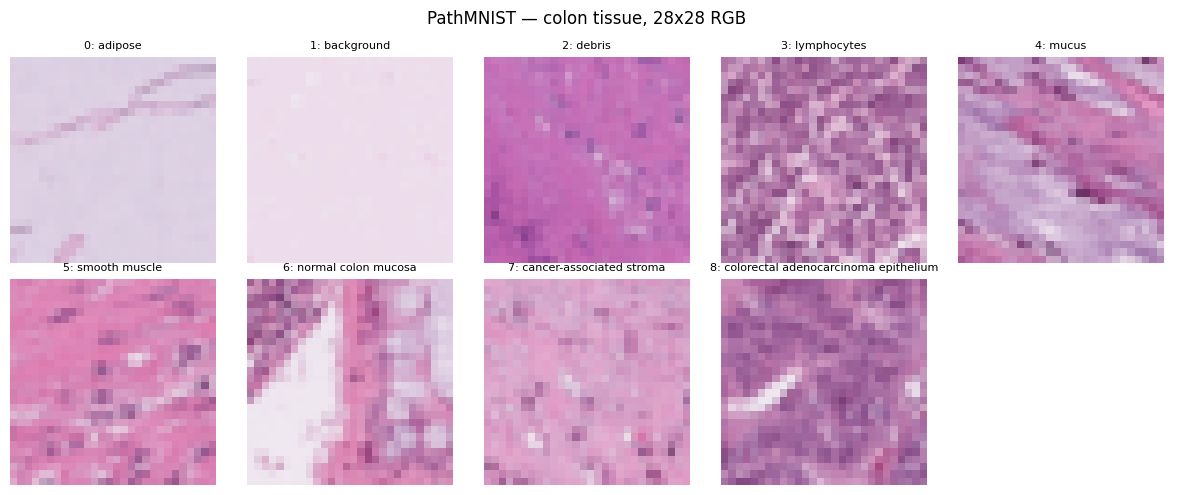

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    if i < n_classes:
        idx = np.where(y_train == i)[0][0]      # first image of class i
        ax.imshow(X_train_img[idx])
        ax.set_title(f"{i}: {class_names[i]}", fontsize=8)
    ax.axis("off")
plt.suptitle("PathMNIST — colon tissue, 28x28 RGB")
plt.tight_layout()
plt.show()

### 3.2 — Class distribution

An **imbalanced** dataset (some classes much rarer than others) pushes a model to ignore the
rare classes. That is exactly why we score with **F1-macro** — the unweighted mean of the
per-class F1 — instead of plain accuracy: it gives every class an equal say.

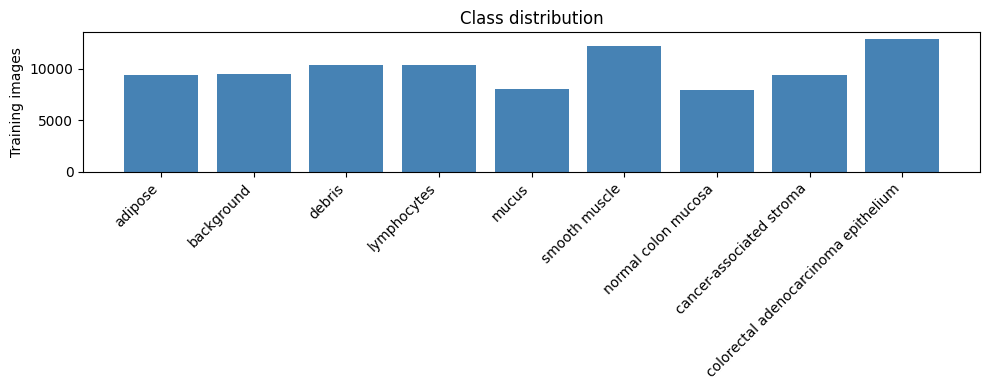

images per class: {0: np.int64(9366), 1: np.int64(9509), 2: np.int64(10360), 3: np.int64(10401), 4: np.int64(8006), 5: np.int64(12182), 6: np.int64(7886), 7: np.int64(9401), 8: np.int64(12885)}


In [5]:
counts = np.bincount(y_train, minlength=n_classes)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(n_classes), counts, color="steelblue")
ax.set_xticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_ylabel("Training images")
ax.set_title("Class distribution")
plt.tight_layout()
plt.show()

print("images per class:", dict(zip(range(n_classes), counts)))

## 4. Prepare the Data

Neural networks expect **normalized float tensors**, not raw `uint8` pixels. Two more steps
matter:

| Step | What | Why |
|---|---|---|
| **To tensor** | `uint8 [0,255]` → `float [0,1]`, shape `H×W×C` → `C×H×W` | PyTorch's image layout |
| **Normalize** | subtract mean, divide by std | centers inputs so training is stable |
| **Augmentation** | random flips / rotations *(train only)* | shows the model more variety → less overfitting |

**Augment the training set only.** The validation/test images must stay untouched so the
score reflects real, unseen data.

In [6]:
mean, std = [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = DataClass(split="train", transform=train_tf, download=True)
test_ds  = DataClass(split="test",  transform=eval_tf,  download=True)

# Subsample the training set so the CNN trains in a couple of minutes. 28x28 patches
# are small, so a fraction of the data is plenty to learn from. Raise this (or remove
# the Subset) to use all 90k images.
SUBSET = 20000
sub_idx = rng.choice(len(train_ds), size=min(SUBSET, len(train_ds)), replace=False)
train_sub = Subset(train_ds, sub_idx)

train_loader = DataLoader(train_sub, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)
print(f"training on {len(train_sub)} images, testing on {len(test_ds)}")

training on 20000 images, testing on 7180


### 4.1 — What augmentation does

The same image, flipped and rotated a few different ways. Each variant is a slightly different training example, which teaches the model that a cell is the same cell regardless of orientation.

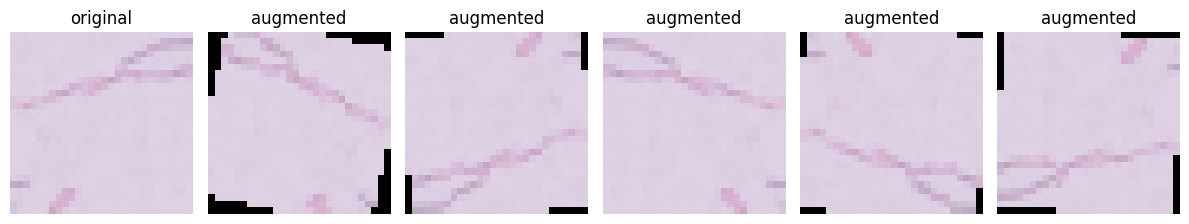

In [7]:
aug_only = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
])
base = transforms.functional.to_pil_image(X_train_img[0])

fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
axes[0].imshow(base); axes[0].set_title("original"); axes[0].axis("off")
for ax in axes[1:]:
    ax.imshow(aug_only(base)); ax.set_title("augmented"); ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Baseline: Logistic Regression on raw pixels

Always start with a **simple model** to set the bar. Here we flatten each image into a vector
of `28·28·3 = 2352` pixel values and fit a logistic regression. It has no notion of *where* a
pixel is or what its neighbours are — so it is exactly the score a real vision model must beat.

In [8]:
X_tr_flat = X_train_img.reshape(len(X_train_img), -1) / 255.0
X_te_flat = X_test_img.reshape(len(X_test_img), -1) / 255.0

# Fit on a subset to keep it quick.
bidx = rng.choice(len(X_tr_flat), size=min(20000, len(X_tr_flat)), replace=False)
scaler = StandardScaler().fit(X_tr_flat[bidx])

logreg = LogisticRegression(max_iter=200)
logreg.fit(scaler.transform(X_tr_flat[bidx]), y_train[bidx])

pred_lr = logreg.predict(scaler.transform(X_te_flat))
acc_lr = accuracy_score(y_test, pred_lr)
f1_lr  = f1_score(y_test, pred_lr, average="macro")
print(f"Logistic Regression (pixels):  accuracy={acc_lr:.4f}   F1-macro={f1_lr:.4f}")

Logistic Regression (pixels):  accuracy=0.5411   F1-macro=0.4496


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 6. A Convolutional Neural Network (from scratch)

A **CNN** slides small learnable filters across the image. Early layers pick up edges and
colours; deeper layers combine those into textures and shapes — the features that actually
distinguish tissue types. Two ideas make it work on images where logistic regression fails:

- **Locality:** each filter looks at a small neighbourhood, so spatial structure is preserved.
- **Weight sharing:** the same filter is reused everywhere, so a pattern is recognised
  wherever it appears (and there are far fewer parameters to learn).

`MaxPool2d` halves the resolution after each block (28 → 14 → 7), and `AdaptiveAvgPool2d(1)`
collapses the final feature map to one value per channel before the classifier.

In [19]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),   # 28 -> 14
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),   # 14 -> 7
            nn.AdaptiveAvgPool2d(1),                                                            # -> 128 x 1 x 1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN(n_classes).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\ntrainable parameters: {n_params:,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=64, out_features=9, bias=True)
  )
)

trainable parameters: 20,169


## 7. Train & Evaluate

Training repeats a simple loop: predict a batch, measure the **loss** (cross-entropy), and
nudge every weight a little in the direction that reduces it (**backpropagation**, via the
Adam optimizer). One pass over the data is an **epoch**. We watch test accuracy each epoch to
make sure the model is genuinely learning and not just memorizing the training set.

In [20]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x = x.to(device)
            y = y.view(-1).long().to(device)
            out = model(x)
            loss = criterion(out, y)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            loss_sum += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            total    += x.size(0)
    return loss_sum / total, correct / total


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10
history = {"train_acc": [], "test_acc": []}
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    te_loss, te_acc = run_epoch(model, test_loader, criterion)
    history["train_acc"].append(tr_acc)
    history["test_acc"].append(te_acc)
    print(f"epoch {epoch}/{EPOCHS}:  train_acc={tr_acc:.4f}  test_acc={te_acc:.4f}")

epoch 1/10:  train_acc=0.5338  test_acc=0.7162
epoch 2/10:  train_acc=0.6504  test_acc=0.7255
epoch 3/10:  train_acc=0.6831  test_acc=0.7471
epoch 4/10:  train_acc=0.7025  test_acc=0.6735
epoch 5/10:  train_acc=0.7228  test_acc=0.6930
epoch 6/10:  train_acc=0.7351  test_acc=0.7085
epoch 7/10:  train_acc=0.7421  test_acc=0.7666
epoch 8/10:  train_acc=0.7510  test_acc=0.6972
epoch 9/10:  train_acc=0.7591  test_acc=0.6595
epoch 10/10:  train_acc=0.7652  test_acc=0.7632


### 7.1 — Learning curve

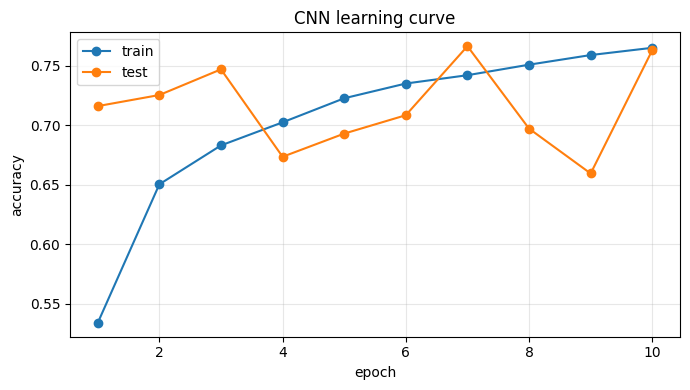

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), history["train_acc"], "o-", label="train")
plt.plot(range(1, EPOCHS + 1), history["test_acc"],  "o-", label="test")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("CNN learning curve")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 — Test-set report

Accuracy alone hides per-class behaviour. The **classification report** shows precision/recall/F1 for every class, and **F1-macro** is the single number we compare models on.

In [14]:
def predict(model, loader):
    model.eval()
    preds, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            preds.append(out.argmax(1).cpu().numpy())
            ys.append(y.view(-1).numpy())
    return np.concatenate(ys), np.concatenate(preds)

y_true_cnn, pred_cnn = predict(model, test_loader)
acc_cnn = accuracy_score(y_true_cnn, pred_cnn)
f1_cnn  = f1_score(y_true_cnn, pred_cnn, average="macro")
print(f"CNN:  accuracy={acc_cnn:.4f}   F1-macro={f1_cnn:.4f}\n")
print(classification_report(y_true_cnn, pred_cnn, target_names=class_names))

CNN:  accuracy=0.7198   F1-macro=0.6721

                                      precision    recall  f1-score   support

                             adipose       0.79      0.67      0.72      1338
                          background       0.87      1.00      0.93       847
                              debris       0.22      0.29      0.25       339
                         lymphocytes       0.99      0.74      0.85       634
                               mucus       0.85      0.64      0.73      1035
                       smooth muscle       0.29      0.46      0.36       592
                 normal colon mucosa       0.84      0.79      0.81       741
            cancer-associated stroma       0.44      0.56      0.49       421
colorectal adenocarcinoma epithelium       0.92      0.89      0.90      1233

                            accuracy                           0.72      7180
                           macro avg       0.69      0.67      0.67      7180
                     

## 8. Transfer Learning with a Pretrained ResNet18

Why learn visual features from scratch when someone already has? **ResNet18** was trained on
ImageNet (1.2M natural images) and its convolutional layers already detect edges, textures
and shapes. We reuse them as a **frozen feature extractor**: push each image through the
network, take the 512-dimensional output, and train a cheap logistic regression on those
features.

Two details matter for a pretrained model:

- **Resize to 224×224** and use **ImageNet normalization** (the mean/std it was trained with).
- We extract features once with `torch.no_grad()` — no expensive training loop needed. This
  is the fastest, most data-efficient way to get a strong model.

In [16]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

resnet_eval_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
resnet_train_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

resnet_train_aug = DataClass(split="train", transform=resnet_train_tf, download=True)  # for fine-tuning
resnet_train_raw = DataClass(split="train", transform=resnet_eval_tf,  download=True)  # for feature extraction
resnet_test_ds   = DataClass(split="test",  transform=resnet_eval_tf,  download=True)

TL_TRAIN = 8000
tl_idx = rng.choice(len(resnet_train_aug), size=min(TL_TRAIN, len(resnet_train_aug)), replace=False)

weights = models.ResNet18_Weights.IMAGENET1K_V1
feat_backbone = models.resnet18(weights=weights)
feat_backbone.fc = nn.Identity()            # drop the 1000-class ImageNet head -> raw 512-d features
for p in feat_backbone.parameters():
    p.requires_grad = False
feat_backbone.eval().to(device)

ftr_loader = DataLoader(Subset(resnet_train_raw, tl_idx), batch_size=64, shuffle=False)
fte_loader = DataLoader(resnet_test_ds,                   batch_size=128, shuffle=False)

def extract_features(backbone, loader):
    feats, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            feats.append(backbone(x.to(device)).cpu().numpy())
            ys.append(y.view(-1).numpy())
    return np.concatenate(feats), np.concatenate(ys)

F_train, yf_train = extract_features(feat_backbone, ftr_loader)
F_test,  yf_test  = extract_features(feat_backbone, fte_loader)
print("feature shape:", F_train.shape)      # (TL_TRAIN, 512)

tl_clf = LogisticRegression(max_iter=1000)
tl_clf.fit(F_train, yf_train)
pred_tl = tl_clf.predict(F_test)
acc_tl = accuracy_score(yf_test, pred_tl)
f1_tl  = f1_score(yf_test, pred_tl, average="macro")
print(f"ResNet18 frozen features + LogReg:  accuracy={acc_tl:.4f}   F1-macro={f1_tl:.4f}")


feature shape: (8000, 512)
ResNet18 frozen features + LogReg:  accuracy=0.8231   F1-macro=0.7546


In [22]:
# =====================================================================
# CELL 2 — Fine-tuning: unfreeze the last block and train end-to-end
# =====================================================================
ft_model = models.resnet18(weights=weights)
ft_model.fc = nn.Linear(ft_model.fc.in_features, n_classes)   # new 9-class head

for p in ft_model.parameters():            # freeze the whole backbone...
    p.requires_grad = False
for p in ft_model.layer4.parameters():     # ...then unfreeze the last block...
    p.requires_grad = True
for p in ft_model.fc.parameters():         # ...and the new head.
    p.requires_grad = True
ft_model.to(device)

n_trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
n_total     = sum(p.numel() for p in ft_model.parameters())
print(f"fine-tuning {n_trainable:,} / {n_total:,} parameters "
      f"({100 * n_trainable / n_total:.0f}% of the network)")

ft_train_loader = DataLoader(Subset(resnet_train_aug, tl_idx), batch_size=64, shuffle=True)
ft_test_loader  = DataLoader(resnet_test_ds,                   batch_size=128, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    {"params": ft_model.layer4.parameters(), "lr": 1e-4},   # gentle on pretrained weights
    {"params": ft_model.fc.parameters(),     "lr": 1e-3},   # faster on the fresh head
])

FT_EPOCHS = 3
for epoch in range(1, FT_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(ft_model, ft_train_loader, criterion, optimizer)
    te_loss, te_acc = run_epoch(ft_model, ft_test_loader,  criterion)
    print(f"epoch {epoch}/{FT_EPOCHS}:  train_acc={tr_acc:.4f}  test_acc={te_acc:.4f}")


fine-tuning 8,398,345 / 11,181,129 parameters (75% of the network)
epoch 1/3:  train_acc=0.8069  test_acc=0.9155
epoch 2/3:  train_acc=0.9036  test_acc=0.9013
epoch 3/3:  train_acc=0.9225  test_acc=0.9035


## 9. Compare the Models

Three approaches, increasing in power. The pixel baseline sets the floor; the CNN *learns*
spatial features; the pretrained backbone *imports* them.

ResNet18 fine-tuned:  accuracy=0.9035   F1-macro=0.8658

                                      precision    recall  f1-score   support

                             adipose       0.98      0.98      0.98      1338
                          background       0.95      1.00      0.98       847
                              debris       0.77      0.82      0.80       339
                         lymphocytes       0.92      0.96      0.94       634
                               mucus       0.99      0.90      0.94      1035
                       smooth muscle       0.74      0.75      0.75       592
                 normal colon mucosa       0.91      0.90      0.91       741
            cancer-associated stroma       0.65      0.53      0.58       421
colorectal adenocarcinoma epithelium       0.90      0.95      0.92      1233

                            accuracy                           0.90      7180
                           macro avg       0.87      0.87      0.87      7180
     

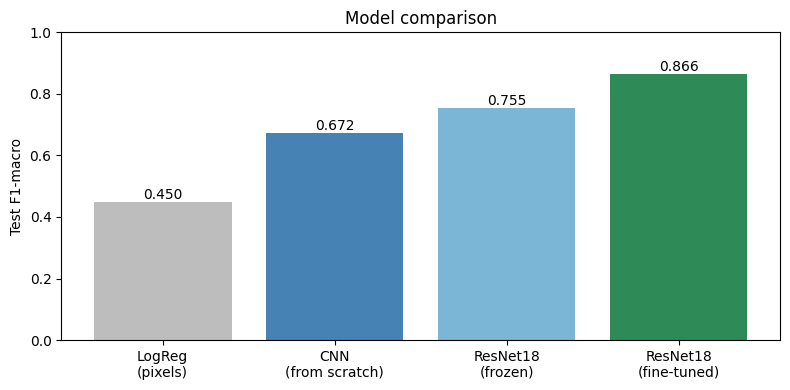

In [23]:

# =====================================================================
# Evaluate & compare all four models (full test set)
# =====================================================================
y_true_ft, pred_ft = predict(ft_model, ft_test_loader)
acc_ft = accuracy_score(y_true_ft, pred_ft)
f1_ft  = f1_score(y_true_ft, pred_ft, average="macro")
print(f"ResNet18 fine-tuned:  accuracy={acc_ft:.4f}   F1-macro={f1_ft:.4f}\n")
print(classification_report(y_true_ft, pred_ft, target_names=class_names))

results = {
    "LogReg\n(pixels)":        f1_lr,
    "CNN\n(from scratch)":     f1_cnn,
    "ResNet18\n(frozen)":      f1_tl,
    "ResNet18\n(fine-tuned)":  f1_ft,
}
plt.figure(figsize=(8, 4))
bars = plt.bar(results.keys(), results.values(),
                color=["#bdbdbd", "steelblue", "#7bb6d6", "seagreen"])
for b, v in zip(bars, results.values()):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center")
plt.ylabel("Test F1-macro"); plt.ylim(0, 1)
plt.title("Model comparison")
plt.tight_layout()
plt.show()